# Credit Card Fraud Detection - Exploratory Data Analysis

This notebook explores the cleaned credit card fraud dataset to understand patterns
before modeling. The dataset is highly imbalanced (~0.17% fraud), so the focus is
on identifying which features distinguish fraudulent transactions from legitimate ones.

In [47]:
# Standard imports for data analysis and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Make plots look nicer and consistent across the notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Show all columns when printing DataFrames
pd.set_option("display.max_columns", None)

## 1. Overview

Load the cleaned dataset and inspect its structure.

In [48]:
# Load the cleaned data we produced in the cleaner step
df = pd.read_csv("../data/cleaned.csv")

# Note the "../" — the notebook is inside notebooks/, so we go up one folder

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Column data types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: 283,726 rows × 31 columns

Column data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Target Analysis

Visualize the class distribution. Because the dataset is highly imbalanced,
we plot counts on a log scale so the rare class is still visible.

Class distribution:
  Legit (0): 283,253 (99.8333%)
  Fraud (1): 473 (0.1667%)


C:\Users\reshm\AppData\Local\Temp\ipykernel_3252\3533318353.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0],
C:\Users\reshm\AppData\Local\Temp\ipykernel_3252\3533318353.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[1],


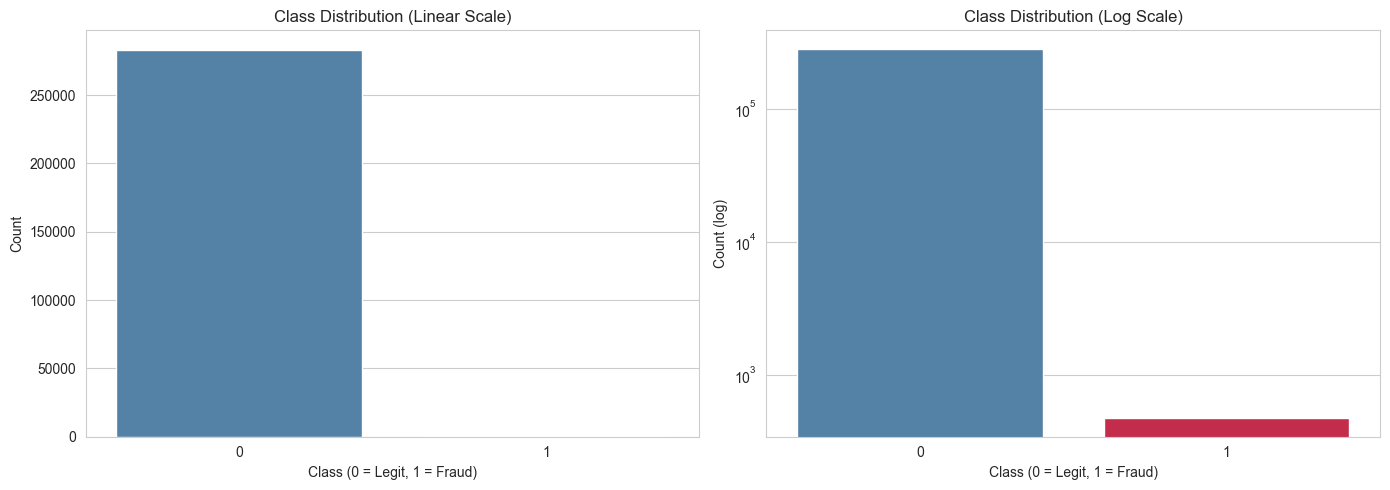

In [ ]:
# Count how many transactions of each class
class_counts = df["Class"].value_counts().sort_index()
class_pcts = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class distribution:")
for cls in class_counts.index:
    label = "Legit (0)" if cls == 0 else "Fraud (1)"
    print(f"  {label}: {class_counts[cls]:,} ({class_pcts[cls]:.4f}%)")
# Two side-by-side plots: linear scale and log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: standard bar chart (fraud bar will be tiny)
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0],
            palette=["steelblue", "crimson"])
axes[0].set_title("Class Distribution (Linear Scale)")
axes[0].set_xlabel("Class (0 = Legit, 1 = Fraud)")
axes[0].set_ylabel("Count")
# Right: log scale so the fraud bar is visible
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[1],
            palette=["steelblue", "crimson"])
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)")
axes[1].set_xlabel("Class (0 = Legit, 1 = Fraud)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()


## 3. Missing Values

Visualize null values across the dataset. We expect zero nulls
since the cleaner already handled them.

Total nulls in dataset: 0
Columns with any nulls: 0


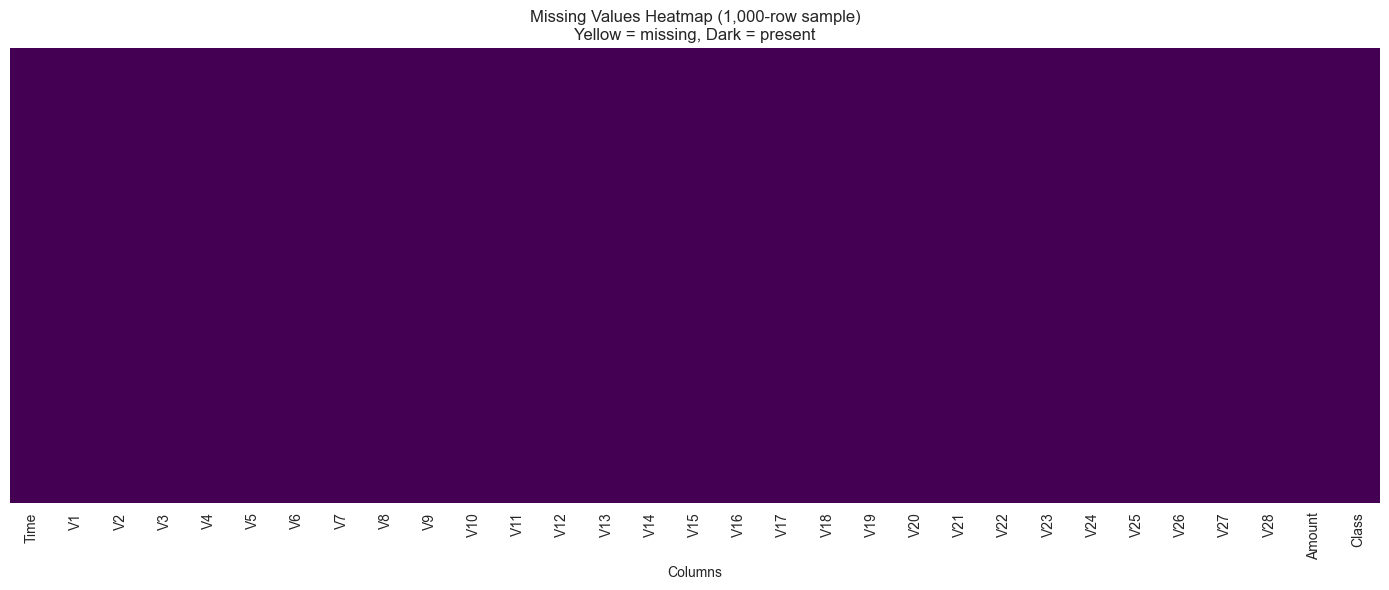

In [50]:
# Count nulls per column
null_counts = df.isnull().sum()
print(f"Total nulls in dataset: {null_counts.sum()}")
print(f"Columns with any nulls: {(null_counts > 0).sum()}")

# Heatmap: shows which cells in the dataset are null
# (we sample 1000 rows because plotting all 283k would be unreadable)
plt.figure(figsize=(14, 6))
sns.heatmap(
    df.sample(1000, random_state=42).isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis",
)
plt.title("Missing Values Heatmap (1,000-row sample)\nYellow = missing, Dark = present")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

## 4. Feature Distributions

Histograms of selected numeric features in a 3×3 grid. The PCA-transformed
features (V1-V28) are centered around zero by construction. Time and Amount
are the original, untransformed features and tell a different story.

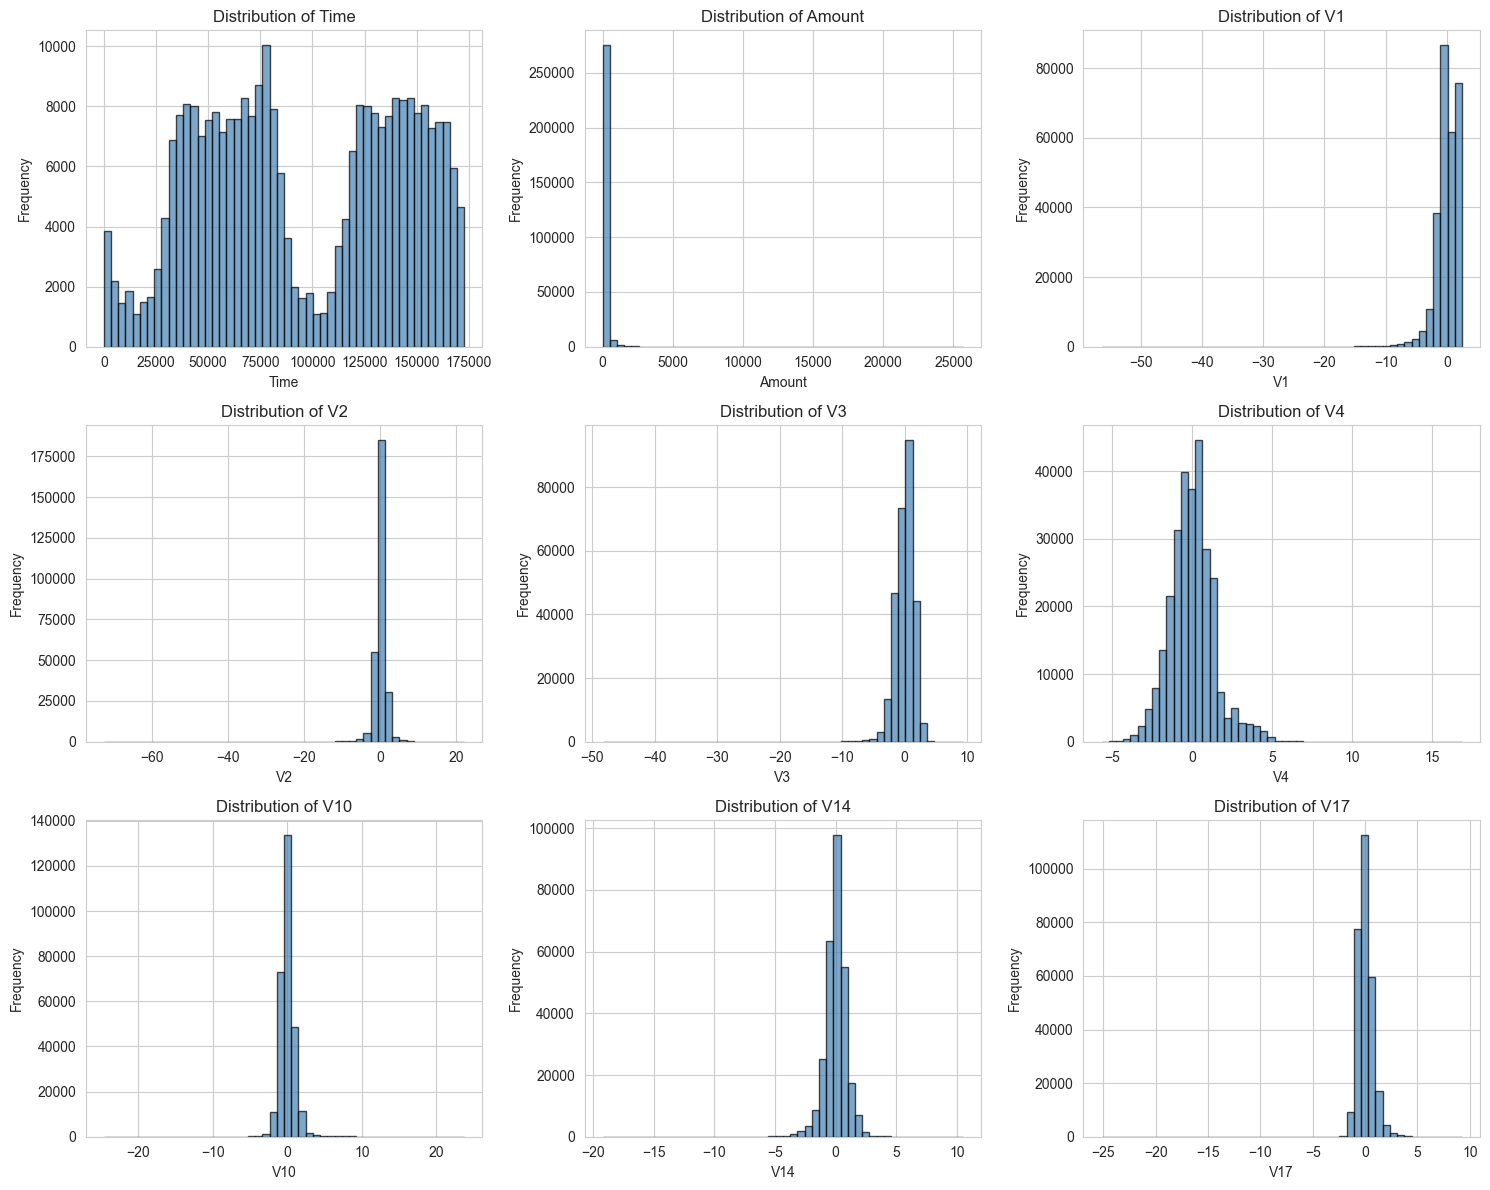

In [51]:
# Pick 9 representative features for a 3x3 grid:
# Time, Amount (the original features), and 7 of the V components
features_to_plot = ["Time", "Amount", "V1", "V2", "V3", "V4", "V10", "V14", "V17"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Turn the 3x3 grid into a flat list for easy iteration

for i, col in enumerate(features_to_plot):
    axes[i].hist(df[col], bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()



## 5. Correlation Matrix

Heatmap of pairwise correlations between numeric features. The PCA-transformed
features V1-V28 are by construction uncorrelated with each other, so we expect
those pairs to be near zero. The interesting cells are correlations between
V features and Class, those reveal which components carry fraud signal.

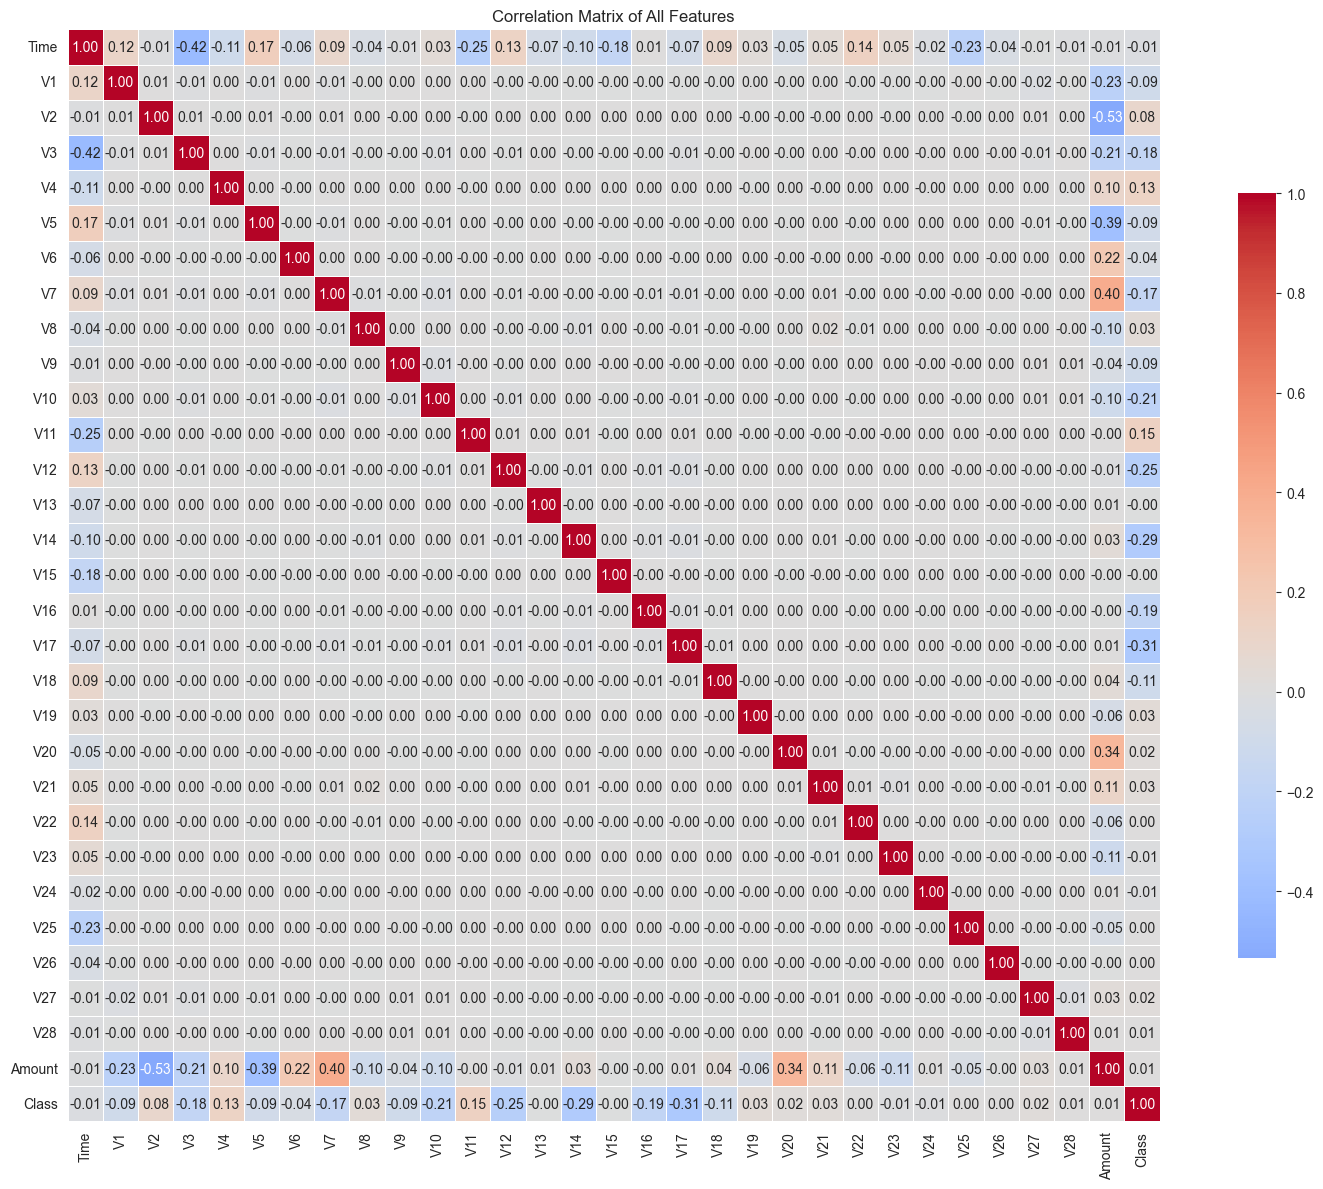


Top features correlated with Class (sorted by absolute correlation):
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


In [52]:
# Compute the correlation matrix
corr = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,         # Print the correlation value in each cell
    annot=True,
    fmt=".2f",          # Round to 2 decimal places
    cmap="coolwarm",    # Red = positive, blue = negative
    center=0,           # Make 0 the white midpoint
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
)
plt.title("Correlation Matrix of All Features")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()


# Print the features most correlated with Class
print("\nTop features correlated with Class (sorted by absolute correlation):")
class_corr = corr["Class"].drop("Class").abs().sort_values(ascending=False)
print(class_corr.head(10))

## 6. Features vs Target

Box plots comparing distributions of the top fraud-correlated features
between legit (0) and fraud (1) transactions. Clear separation between
the two boxes means the feature is useful for distinguishing fraud.

Plotting top 3 fraud-correlated features: ['V17', 'V14', 'V12']


C:\Users\reshm\AppData\Local\Temp\ipykernel_3252\1179656204.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=col, ax=axes[i],
C:\Users\reshm\AppData\Local\Temp\ipykernel_3252\1179656204.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=col, ax=axes[i],
C:\Users\reshm\AppData\Local\Temp\ipykernel_3252\1179656204.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=col, ax=axes[i],


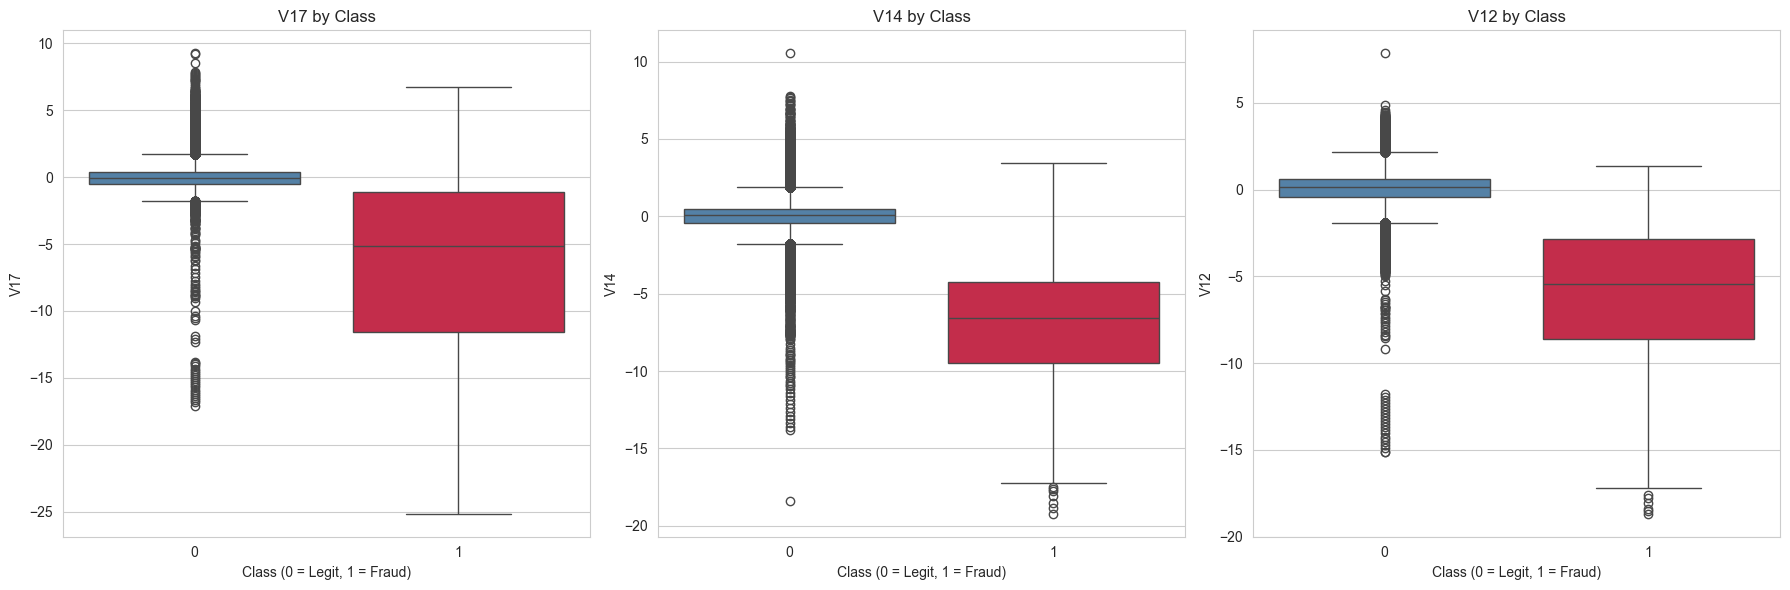

In [53]:
# Get the top 3 features most correlated with Class (computed in previous cell)
top_features = class_corr.head(3).index.tolist()
print(f"Plotting top 3 fraud-correlated features: {top_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(top_features):
    sns.boxplot(data=df, x="Class", y=col, ax=axes[i],
                palette=["steelblue", "crimson"])
    axes[i].set_title(f"{col} by Class")
    axes[i].set_xlabel("Class (0 = Legit, 1 = Fraud)")
    axes[i].set_ylabel(col)


plt.tight_layout()
plt.show()

## 7. Key Findings

Patterns discovered during EDA of the cleaned dataset (283,726 rows):

- **Severe class imbalance confirmed visually:** Fraud (Class 1) is invisible
  on a linear bar chart and only becomes visible on a log scale. Legit
  transactions sit around 10^5, fraud around 10^2.6, roughly 600:1 ratio.

- **No missing values:** The heatmap is entirely dark and confirms zero nulls
  across all 31 columns. No imputation needed.

- **Time is bimodal:** The Time distribution shows two clear peaks separated
  by a low activity valley around the 100,000-second mark. This matches the
  dataset spanning ~2 days with overnight quiet periods. Time of day may
  carry signal but probably needs feature engineering (e.g. hour-of-day)
  to be useful.

- **Amount is extremely right-skewed:** Almost all transactions sit near $0,
  with a thin tail stretching to $25,000. A log transform or a robust scaler
  will likely help any linear model. Interestingly, Amount has essentially
  zero direct correlation with Class (0.01), transaction size alone does
  not distinguish fraud.

- **Top fraud-correlated features are V17, V14, V12, V10, V16, V3, V7:**
  All show negative correlation with Class in the range -0.17 to -0.31.
  V17 is the single strongest predictor at -0.31.

- **Box plots show dramatic separation:** For V17, V14, and V12, the legit
  class is tightly centered around 0, while fraud sits at roughly -5 to -6
  with a much wider spread. The interquartile ranges barely overlap. These
  features alone should give a model strong predictive power.

- **PCA features are decorrelated, as expected:** Cells off the diagonal
  among V1–V28 are essentially all 0.00, confirming the orthogonality that
  PCA guarantees by construction. No redundancy concerns among the V
  components.